In [25]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('../data/data_bank_marketing_campaign.csv')
df.head()

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


In [26]:
# Preprocessing 
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier 

# Evaluation 
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, recall_score, precision_score
)

# Save model
import pickle

print('Semua library berhasil di import!')

Semua library berhasil di import!


In [27]:
# Load Data 
df = pd.read_csv('../data/data_bank_marketing_campaign.csv')
print(f'Total rows   : {df.shape[0]}')
print(f'Total columns   : {df.shape[1]}')
print()
df.head()

Total rows   : 7813
Total columns   : 11



,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


In [28]:
# Info Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       7813 non-null   int64 
 1   job       7813 non-null   object
 2   balance   7813 non-null   int64 
 3   housing   7813 non-null   object
 4   loan      7813 non-null   object
 5   contact   7813 non-null   object
 6   month     7813 non-null   object
 7   campaign  7813 non-null   int64 
 8   pdays     7813 non-null   int64 
 9   poutcome  7813 non-null   object
 10  deposit   7813 non-null   object
dtypes: int64(4), object(7)
memory usage: 671.6+ KB


In [29]:
# Statistik Deskriptif
df.describe()

,age,balance,campaign,pdays
count,7813.000000,7813.000000,7813.000000,7813.000000
mean,41.257264,1512.448611,2.519775,51.408550
std,11.919710,3089.291831,2.727001,108.072739
min,18.000000,-6847.000000,1.000000,-1.000000
25%,32.000000,127.000000,1.000000,-1.000000
50%,39.000000,549.000000,2.000000,-1.000000
75%,49.000000,1684.000000,3.000000,40.000000
max,95.000000,66653.000000,63.000000,854.000000


In [30]:
# Cek Distribusi Target
print('Distribusi Target (deposit):')
print(df['deposit'].value_counts())
print()
print('Proporsi (%):')
print(df['deposit'].value_counts(normalize=True).round(4) * 100)

Distribusi Target (deposit):
deposit
no     4081
yes    3732
Name: count, dtype: int64

Proporsi (%):
deposit
no     52.23
yes    47.77
Name: proportion, dtype: float64


DATA CLEANING, FEATURE SELECTION AND FEATURE ENGINEERING

In [31]:
# Missing Values
print('Missing Values per Kolom:')
missing = df.isnull().sum()
print(missing)
print()
print(f'Total missing values: {missing.sum()}')

Missing Values per Kolom:
age         0
job         0
balance     0
housing     0
loan        0
contact     0
month       0
campaign    0
pdays       0
poutcome    0
deposit     0
dtype: int64

Total missing values: 0


In [32]:
# Cek Duplikat 
print(f'Jumlah duplikat: {df.duplicated().sum()}')

Jumlah duplikat: 8


In [33]:
# Outlier Detection 
num_cols = ['age', 'balance', 'campaign', 'pdays']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f'{col}: {outliers} outlier(s) | range valid [{lower:.1f}, {upper:.1f}]')

age: 121 outlier(s) | range valid [6.5, 74.5]
balance: 736 outlier(s) | range valid [-2208.5, 4019.5]
campaign: 429 outlier(s) | range valid [-2.0, 6.0]
pdays: 1454 outlier(s) | range valid [-62.5, 101.5]


In [34]:
# Capping Outlier
df_clean = df.copy()

cap_cols = ['balance', 'campaign']  # 2 kolom dengan outlier signifikan

for col in cap_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)
    print(f'[CAPPED] {col}: nilai di luar [{lower:.1f}, {upper:.1f}] sudah di-cap')

print()
print('Shape setelah cleaning:', df_clean.shape)

[CAPPED] balance: nilai di luar [-2208.5, 4019.5] sudah di-cap
[CAPPED] campaign: nilai di luar [-2.0, 6.0] sudah di-cap

Shape setelah cleaning: (7813, 11)


In [35]:
# Feature Engineering 

# 1. was_contacted_before: Has the customer been contacted before?
#    pdays = -1 means not yet → 0, others → 1
df_clean['was_contacted_before'] = (df_clean['pdays'] != -1).astype(int)
print('✅ Feature was_contacted_before dibuat')

# 2. age_group
bins = [0, 30, 40, 50, 60, 100]
labels = ['<30', '30-39', '40-49', '50-59', '60+']
df_clean['age_group'] = pd.cut(df_clean['age'], bins=bins, labels=labels)
print('✅ Feature age_group dibuat')

# 3. balance_category:
df_clean['balance_category'] = pd.cut(
    df_clean['balance'],
    bins=[-float('inf'), 0, 500, 2000, float('inf')],
    labels=['negatif', 'rendah', 'sedang', 'tinggi']
)
print('✅ Feature balance_category dibuat')

print()
print('Preview:')
df_clean[['age', 'age_group', 'balance', 'balance_category', 'pdays', 'was_contacted_before']].head()

✅ Feature was_contacted_before dibuat
✅ Feature age_group dibuat
✅ Feature balance_category dibuat

Preview:


,age,age_group,balance,balance_category,pdays,was_contacted_before
0,55,50-59,1662.0,sedang,-1,0
1,39,30-39,-2208.5,negatif,-1,0
2,51,50-59,3025.0,tinggi,352,1
3,38,30-39,-87.0,negatif,-1,0
4,36,30-39,205.0,rendah,-1,0


In [36]:
# Encoding
df_encoded = df_clean.copy()

# Binary encoding (yes/no → 1/0)
binary_cols = ['housing', 'loan']
for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes': 1, 'no': 0})

# Label encode target
df_encoded['deposit'] = df_encoded['deposit'].map({'yes': 1, 'no': 0})

# One-Hot Encoding untuk kolom nominal
ohe_cols = ['job', 'contact', 'month', 'poutcome', 'age_group', 'balance_category']
df_encoded = pd.get_dummies(df_encoded, columns=ohe_cols, drop_first=True)

# Drop kolom yang sudah tidak dibutuhkan
df_encoded = df_encoded.drop(columns=['pdays'])
# Alasan drop pdays: sudah direpresentasikan oleh was_contacted_before

print('Shape setelah encoding:', df_encoded.shape)
print()
print('Kolom hasil encoding:')
print(df_encoded.columns.tolist())

Shape setelah encoding: (7813, 41)

Kolom hasil encoding:
['age', 'balance', 'housing', 'loan', 'campaign', 'deposit', 'was_contacted_before', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired', 'job_self-employed', 'job_services', 'job_student', 'job_technician', 'job_unemployed', 'job_unknown', 'contact_telephone', 'contact_unknown', 'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown', 'age_group_30-39', 'age_group_40-49', 'age_group_50-59', 'age_group_60+', 'balance_category_rendah', 'balance_category_sedang', 'balance_category_tinggi']


SPLIT DATA AND SCALING

In [37]:
# Define X dan y
X = df_encoded.drop(columns=['deposit'])
y = df_encoded['deposit']

print('Shape X:', X.shape)
print('Shape y:', y.shape)
print()
print('Distribusi target:')
print(y.value_counts())

Shape X: (7813, 40)
Shape y: (7813,)

Distribusi target:
deposit
0    4081
1    3732
Name: count, dtype: int64


In [38]:
# Train-Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # reproducibility
    stratify=y           # menjaga proporsi target di train & test
)

print(f'Train size : {X_train.shape[0]} baris')
print(f'Test size  : {X_test.shape[0]} baris')
print()
print('Distribusi target di train set:')
print(y_train.value_counts(normalize=True).round(4) * 100)
print()
print('Distribusi target di test set:')
print(y_test.value_counts(normalize=True).round(4) * 100)

Train size : 6250 baris
Test size  : 1563 baris

Distribusi target di train set:
deposit
0    52.24
1    47.76
Name: proportion, dtype: float64

Distribusi target di test set:
deposit
0    52.21
1    47.79
Name: proportion, dtype: float64


In [39]:
# Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled  = scaler.transform(X_test)        

print('✅ Scaling selesai.')
print('Catatan: fit_transform hanya di train set untuk menghindari data leakage.')

✅ Scaling selesai.
Catatan: fit_transform hanya di train set untuk menghindari data leakage.


ANALYTICS - MODELING AND EVALUATION MATRICS

In [40]:
# Model Comparison (Baseline)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=42),
    'XGBoost'            : XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    recall    = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    f1        = f1_score(y_test, y_pred)
    roc_auc   = roc_auc_score(y_test, y_proba)
    
    results.append({
        'Model'    : name,
        'Recall'   : round(recall, 4),
        'Precision': round(precision, 4),
        'F1-Score' : round(f1, 4),
        'ROC AUC'  : round(roc_auc, 4)
    })
    print(f'[{name}] Recall: {recall:.4f} | F1: {f1:.4f} | ROC AUC: {roc_auc:.4f}')

results_df = pd.DataFrame(results).sort_values('Recall', ascending=False)
print()
results_df

[Logistic Regression] Recall: 0.6225 | F1: 0.6884 | ROC AUC: 0.7904
[Decision Tree] Recall: 0.6091 | F1: 0.6055 | ROC AUC: 0.6210
[Random Forest] Recall: 0.6212 | F1: 0.6667 | ROC AUC: 0.7538
[Gradient Boosting] Recall: 0.6238 | F1: 0.6904 | ROC AUC: 0.7938
[XGBoost] Recall: 0.6198 | F1: 0.6648 | ROC AUC: 0.7533



,Model,Recall,Precision,F1-Score,ROC AUC
3,Gradient Boosting,0.6238,0.7728,0.6904,0.7938
0,Logistic Regression,0.6225,0.7699,0.6884,0.7904
2,Random Forest,0.6212,0.7194,0.6667,0.7538
4,XGBoost,0.6198,0.7167,0.6648,0.7533
1,Decision Tree,0.6091,0.6019,0.6055,0.6210


In [41]:
# Hyperparameter Tuning (GridSearchCV)
param_grid = {
    'n_estimators'    : [100, 200],
    'max_depth'       : [3, 5, 7],
    'learning_rate'   : [0.05, 0.1, 0.2],
    'subsample'       : [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0)

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='recall',    # fokus pada recall sesuai business priority
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print('Best Parameters:')
print(grid_search.best_params_)
print(f'\nBest CV Recall Score: {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1.0}

Best CV Recall Score: 0.6375


In [42]:
# Final Model
best_model = grid_search.best_estimator_

y_pred_final = best_model.predict(X_test_scaled)
y_proba_final = best_model.predict_proba(X_test_scaled)[:, 1]

print('=== FINAL MODEL PERFORMANCE ===')
print()
print(classification_report(y_test, y_pred_final, target_names=['No (0)', 'Yes (1)']))
print(f'ROC AUC Score : {roc_auc_score(y_test, y_proba_final):.4f}')

=== FINAL MODEL PERFORMANCE ===

              precision    recall  f1-score   support

      No (0)       0.69      0.76      0.72       816
     Yes (1)       0.70      0.63      0.66       747

    accuracy                           0.69      1563
   macro avg       0.70      0.69      0.69      1563
weighted avg       0.70      0.69      0.69      1563

ROC AUC Score : 0.7449


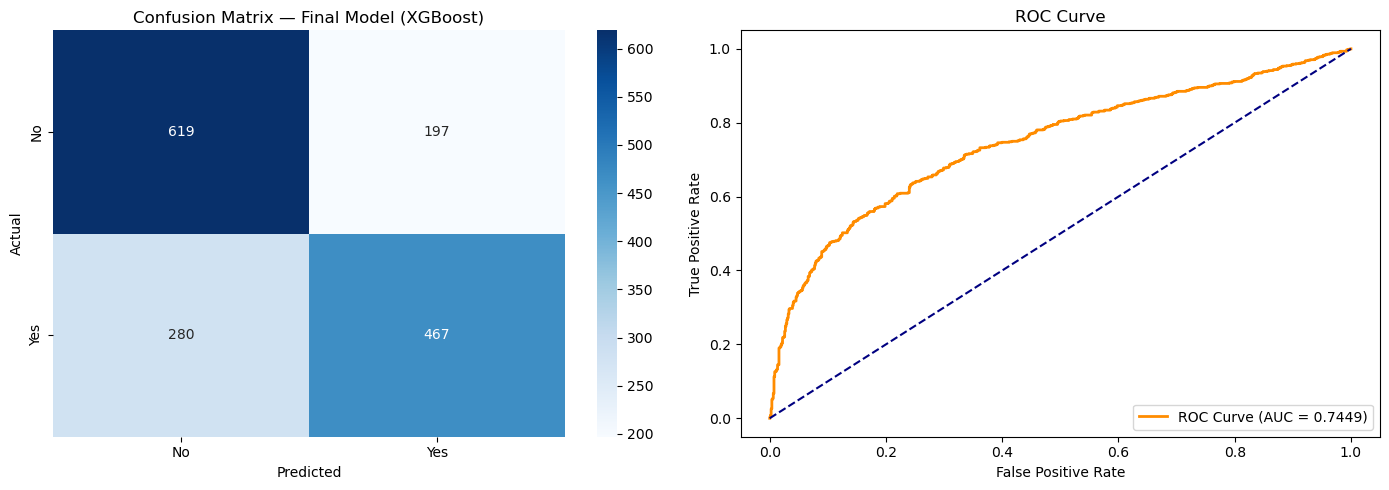

In [43]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], ax=axes[0])
axes[0].set_title('Confusion Matrix — Final Model (XGBoost)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba_final)
auc_score = roc_auc_score(y_test, y_proba_final)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

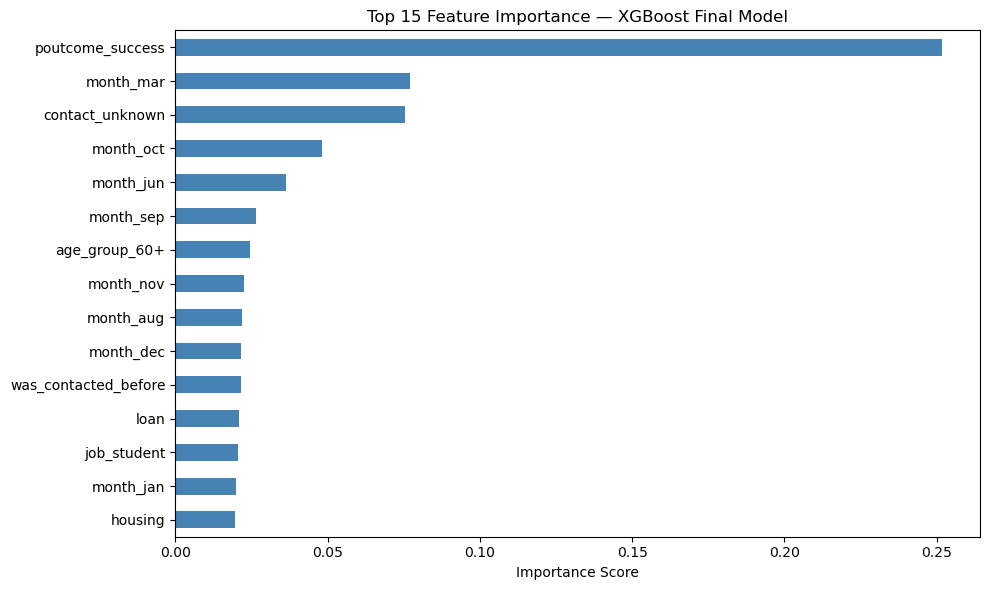

poutcome_success        0.251624
month_mar               0.077139
contact_unknown         0.075290
month_oct               0.048058
month_jun               0.036214
month_sep               0.026461
age_group_60+           0.024590
month_nov               0.022482
month_aug               0.021957
month_dec               0.021599
was_contacted_before    0.021583
loan                    0.021052
job_student             0.020513
month_jan               0.019908
housing                 0.019710
dtype: float32


In [44]:
# Feature Importance
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importance — XGBoost Final Model')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(feat_imp)

CROSS VALIDATION

In [45]:
# Cross Validation
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='recall')

print('Cross Validation Recall Scores (5-fold):')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {score:.4f}')
print(f'\nMean CV Recall  : {cv_scores.mean():.4f}')
print(f'Std CV Recall   : {cv_scores.std():.4f}')
print()
print(f'Test Recall     : {recall_score(y_test, y_pred_final):.4f}')
print()
print('Interpretasi: Jika mean CV dan test recall relatif dekat, model tidak overfitting.')

Cross Validation Recall Scores (5-fold):
  Fold 1: 0.6616
  Fold 2: 0.6382
  Fold 3: 0.5946
  Fold 4: 0.6533
  Fold 5: 0.6399

Mean CV Recall  : 0.6375
Std CV Recall   : 0.0231

Test Recall     : 0.6252

Interpretasi: Jika mean CV dan test recall relatif dekat, model tidak overfitting.


In [46]:
# Business Impact Simulation
tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()

total_contacts_tanpa_model = len(y_test)
total_contacts_dengan_model = tp + fp  

conversion_rate_tanpa_model = (y_test == 1).sum() / len(y_test)
conversion_rate_dengan_model = tp / (tp + fp) if (tp + fp) > 0 else 0

print('=== SIMULASI DAMPAK BISNIS ===')
print(f'Total nasabah di test set           : {len(y_test)}')
print(f'Nasabah yang benar-benar mau (yes)  : {(y_test==1).sum()}')
print()
print(f'TANPA MODEL (kontak semua orang):')
print(f'  - Jumlah kontak               : {total_contacts_tanpa_model}')
print(f'  - Conversion rate             : {conversion_rate_tanpa_model:.2%}')
print()
print(f'DENGAN MODEL (kontak prediksi yes saja):')
print(f'  - Jumlah kontak               : {total_contacts_dengan_model}')
print(f'  - Berhasil subscribe (TP)     : {tp}')
print(f'  - Missed (FN)                 : {fn}')
print(f'  - Conversion rate             : {conversion_rate_dengan_model:.2%}')
print(f'  - Penghematan kontak          : {total_contacts_tanpa_model - total_contacts_dengan_model} panggilan')
print(f'  - Efisiensi                   : {(1 - total_contacts_dengan_model/total_contacts_tanpa_model):.2%} lebih sedikit kontak')

=== SIMULASI DAMPAK BISNIS ===
Total nasabah di test set           : 1563
Nasabah yang benar-benar mau (yes)  : 747

TANPA MODEL (kontak semua orang):
  - Jumlah kontak               : 1563
  - Conversion rate             : 47.79%

DENGAN MODEL (kontak prediksi yes saja):
  - Jumlah kontak               : 664
  - Berhasil subscribe (TP)     : 467
  - Missed (FN)                 : 280
  - Conversion rate             : 70.33%
  - Penghematan kontak          : 899 panggilan
  - Efisiensi                   : 57.52% lebih sedikit kontak


In [47]:
# Save Model dengan Pickle
with open('model_bank_marketing.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('scaler_bank_marketing.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('✅ Model berhasil disimpan: model_bank_marketing.pkl')
print('✅ Scaler berhasil disimpan: scaler_bank_marketing.pkl')

# Verifikasi load model
with open('model_bank_marketing.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

y_pred_check = loaded_model.predict(X_test_scaled[:5])
print()
print('Verifikasi loaded model (5 prediksi pertama):', y_pred_check)

✅ Model berhasil disimpan: model_bank_marketing.pkl
✅ Scaler berhasil disimpan: scaler_bank_marketing.pkl

Verifikasi loaded model (5 prediksi pertama): [0 1 1 0 0]
